In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/raw/creditcard.csv")

In [7]:
print(f"Shape: \n {df.shape}")
print(f"Head: \n {df.head()}")
print(f"Info: \n {df.info()}")
print(f"Describe: \n {df.describe()}")
print(f"Пропусков {df.isnull().sum().sum()}")
print(f"Дубликатов {df.duplicated().sum()}")

Shape: 
 (284807, 31)
Head: 
    Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

  

In [8]:
df_clean = df.drop_duplicates().reset_index(drop=True).copy()
print(f"Количество фрода до удаления {(df['Class'] == 1).sum()}")
print(f"Количество фрода после удаления {(df_clean['Class'] == 1).sum()}")
print(f"Процент машенников до {df['Class'].mean():.4%}")
print(f"Процент машенников после {df_clean['Class'].mean():.4%}")
df = df_clean


Количество фрода до удаления 492
Количество фрода после удаления 473
Процент машенников до 0.1727%
Процент машенников после 0.1667%


**Detection rate:** 1 фрод на 599 транзакций

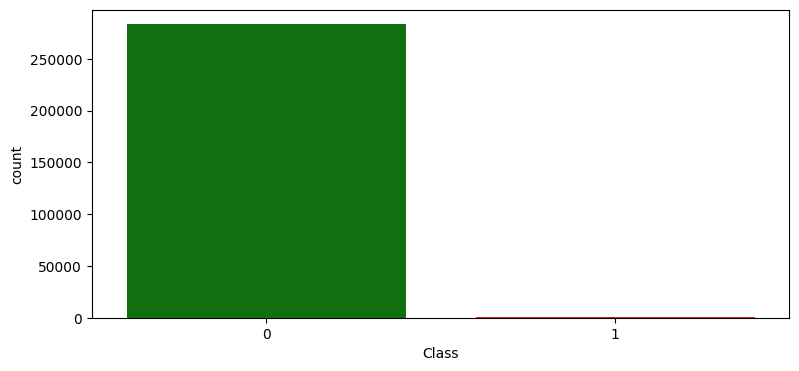

In [9]:
from IPython.display import display, Markdown

plt.figure(figsize=(9, 4))
sns.countplot(data=df, x='Class', hue='Class', legend=False, palette=['green', 'red'])

class_count = df["Class"].value_counts()
frauds = class_count[1]
transactions = class_count[0]
ratio = transactions/frauds
display(Markdown(f"**Detection rate:** 1 фрод на {ratio:.0f} транзакций"))
                

In [10]:
df.groupby('Class')['Amount'].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,283253.0,88.413575,250.379023,0.0,5.67,22.00,77.46,25691.16
1,473.0,123.871860,260.211041,0.0,1.00,9.82,105.89,2125.87


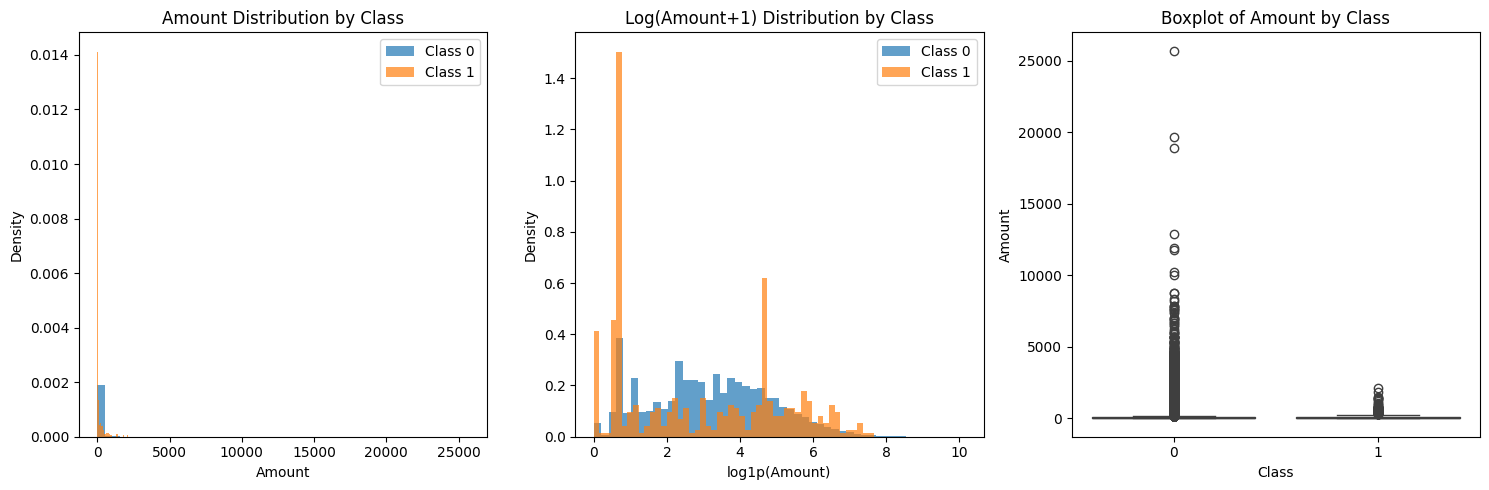

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].hist(df[df['Class'] == 0]['Amount'], bins=50, alpha=0.7, label='Class 0', density=True)
axes[0].hist(df[df['Class'] == 1]['Amount'], bins=50, alpha=0.7, label='Class 1', density=True)
axes[0].set_title('Amount Distribution by Class')
axes[0].set_xlabel('Amount')
axes[0].set_ylabel('Density')
axes[0].legend()


log_amount = np.log1p(df['Amount'])

axes[1].hist(log_amount[df['Class'] == 0], bins=50, alpha=0.7, label='Class 0', density=True)
axes[1].hist(log_amount[df['Class'] == 1], bins=50, alpha=0.7, label='Class 1', density=True)
axes[1].set_title('Log(Amount+1) Distribution by Class')
axes[1].set_xlabel('log1p(Amount)')
axes[1].set_ylabel('Density')
axes[1].legend()


sns.boxplot(x='Class', y='Amount', data=df, ax=axes[2])
axes[2].set_title('Boxplot of Amount by Class')
axes[2].set_xlabel('Class')
axes[2].set_ylabel('Amount')


plt.tight_layout()
plt.show()

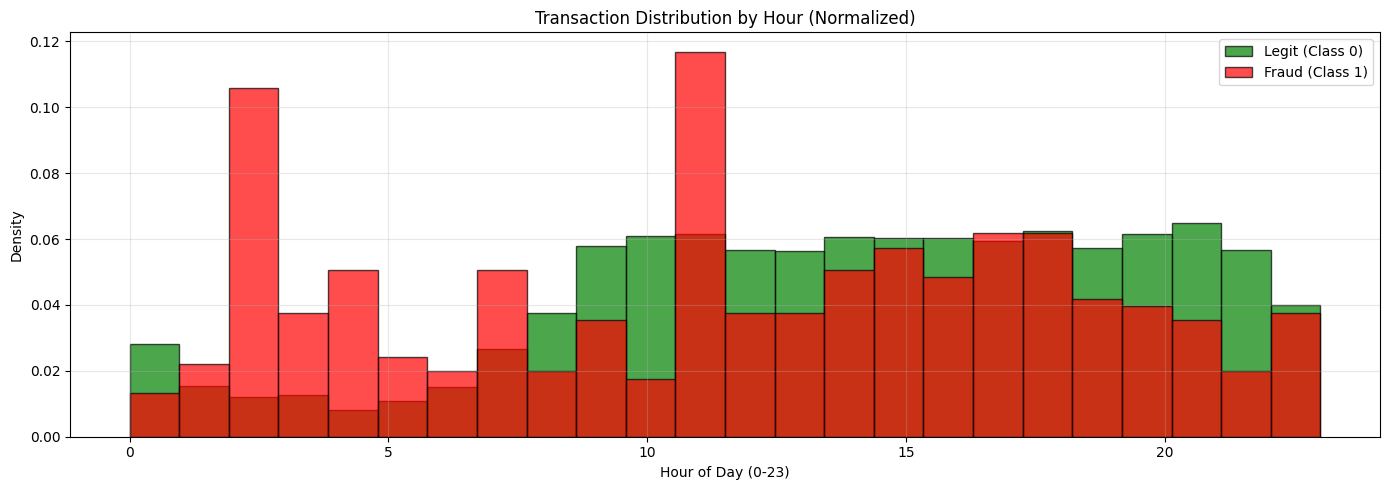

In [12]:
hour = (df['Time'] // 3600) % 24


fig, axes = plt.subplots(1, 1, figsize=(14, 5))
axes.hist(hour[df['Class'] == 0], bins=24, alpha=0.7, 
             label='Legit (Class 0)', density=True, color='green', edgecolor='black')
axes.hist(hour[df['Class'] == 1], bins=24, alpha=0.7, 
             label='Fraud (Class 1)', density=True, color='red', edgecolor='black')
axes.set_title('Transaction Distribution by Hour (Normalized)', fontsize=12)
axes.set_xlabel('Hour of Day (0-23)', fontsize=10)
axes.set_ylabel('Density', fontsize=10)
axes.legend()
axes.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [13]:
corr = df.corr()['Class'].drop('Class').sort_values()
print(corr)


V17      -0.313498
V14      -0.293375
V12      -0.250711
V10      -0.206971
V16      -0.187186
V3       -0.182322
V7       -0.172347
V18      -0.105340
V1       -0.094486
V9       -0.094021
V5       -0.087812
V6       -0.043915
Time     -0.012359
V24      -0.007210
V23      -0.006333
V13      -0.003897
V15      -0.003300
V25       0.003202
V26       0.004265
V22       0.004887
Amount    0.005777
V28       0.009682
V20       0.021486
V27       0.021892
V21       0.026357
V8        0.033068
V19       0.033631
V2        0.084624
V4        0.129326
V11       0.149067
Name: Class, dtype: float64


In [14]:
top10 = corr.abs().nlargest(10)
print(top10)


V17    0.313498
V14    0.293375
V12    0.250711
V10    0.206971
V16    0.187186
V3     0.182322
V7     0.172347
V11    0.149067
V4     0.129326
V18    0.105340
Name: Class, dtype: float64


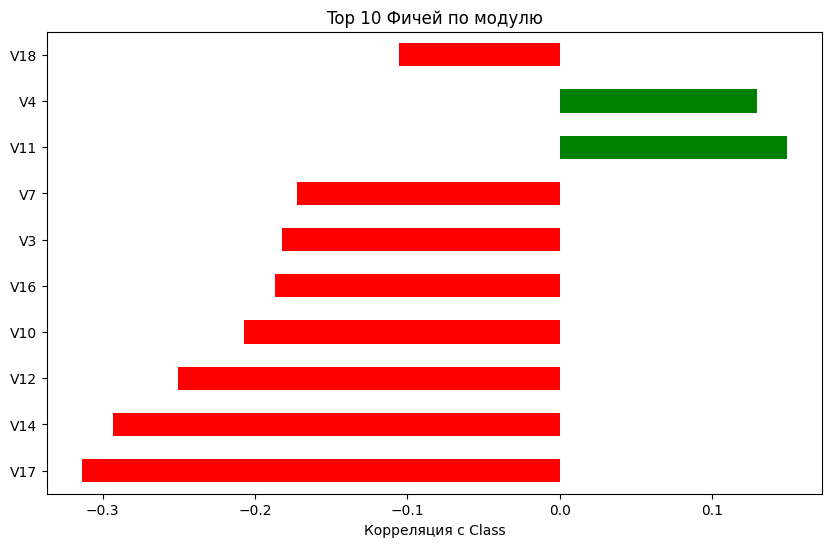

In [15]:
plt.figure(figsize=(10, 6))
corr[top10.index].plot(kind='barh', color=['red' if x < 0 else 'green' for x in corr[top10.index]])
plt.xlabel('Корреляция с Class')
plt.title('Top 10 Фичей по модулю')
plt.show()

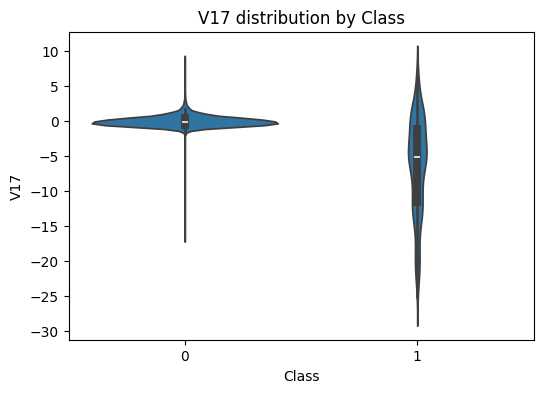

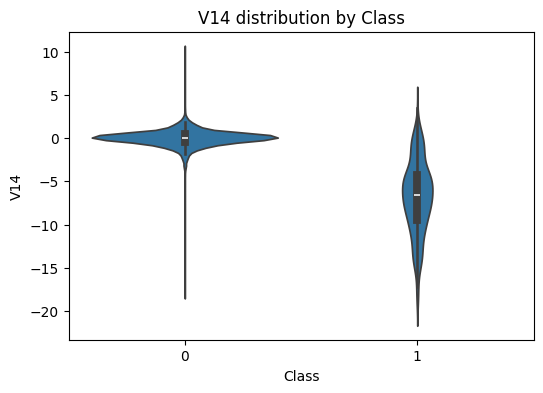

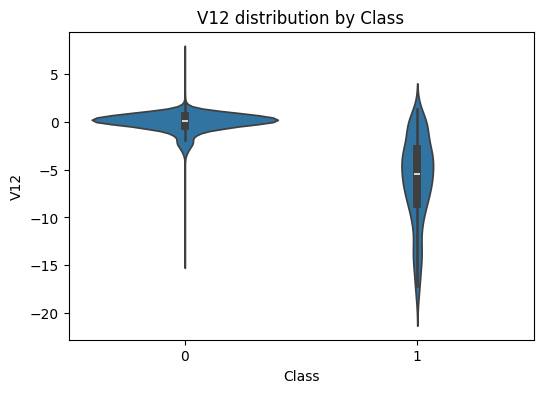

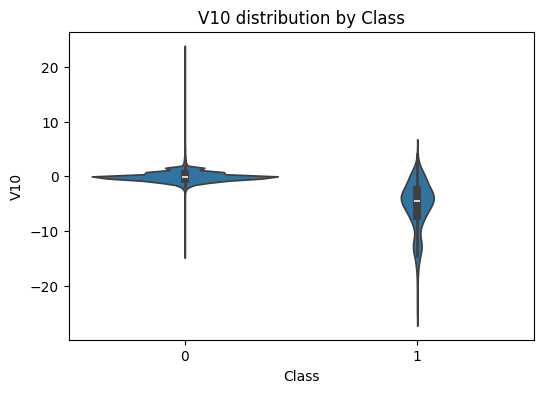

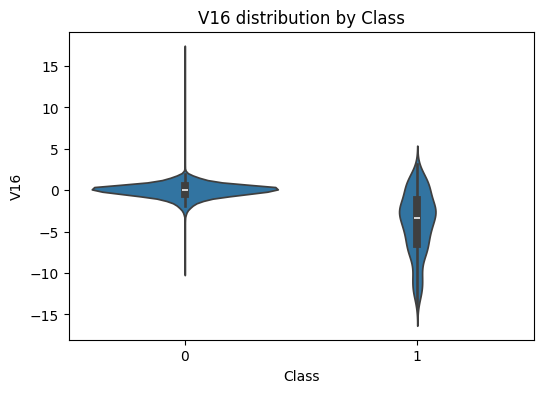

In [16]:
top5 = top10.head(5).index

for feature in top5:
    plt.figure(figsize=(6, 4))
    sns.violinplot(x='Class', y=feature, data=df)
    plt.title(f'{feature} distribution by Class')
    plt.show()

# Выводы по данным 

## Размер данных. дисбаланс
Размер датасета 284807 с 31 признаком

Присутствует дисбаланс: количество мошеннических операций 0.17%

## Пропуски/Дубликаты
Пропусков нет
Обнаруженно 1081 дубликат

## Amount и Time
### Анализ Amount

Распределение **Amount** сильно скошено вправо (long tail). Для анализа использован `log1p(Amount)`.

### Ключевые наблюдения:

- **Фрод-транзакции** концентрируются в зоне малых сумм (особенно ~0–2$ и ~99$). Это согласуется с известным паттерном *"card testing"* — мошенники проверяют карту микро-транзакциями.

- **Крупные транзакции** (>2500$) — почти исключительно легитимные.

- Распределения **Amount** для двух классов различаются → признак несёт полезный сигнал для модели.

### Анализ Time


### Ключевые наблюдения:
Признак Hour создан как (Time // 3600) % 24. Поскольку Time — это секунды от первой транзакции, а не реальное время суток, Hour отражает условный циклический паттерн, а не реальные часы дня.
Тем не менее, распределения фрода и легитимных транзакций по этому условному часу различаются — значит, признак несёт некоторый сигнал и его стоит оставить.


# V-признаки 
## Анализ V-признаков: разделяющая способность

### Лучшие признаки (топ-3):
1. **V17** — наибольший диапазон -0.31
2. **V14** — второй по информативности -0.29
3. **V12** — стабильно отрицательный -0.25

### Ключевые наблюдения:
-Признаки V17, V14, V12, V10, V16, V3, V7 имеют отрицательную корреляцию с фродом — у мошеннических транзакций их значения сдвинуты вниз.
-Признаки V11, V4, V2 имеют положительную корреляцию — у фрода их значения сдвинуты вверх.
-На violin plots видно, что распределения для Class=0 и Class=1 заметно различаются у топ-признаков → они хорошо разделяют классы.

### Вывод:
V17, V14 и V12 — наиболее ценные признаки для обнаружения фрода.

# Планы на preprocessing
- Удалить дубликаты(1081)
- Создать признаки log1p_Amount и Hour
- Применить StandardScaler к Amount и Time (V-признаки уже стандартизированы)
- Сделать stratified train/test split (из-за сильного дисбаланса)
- Для борьбы с дисбалансом рассмотреть: class_weight='balanced', SMOTE, undersampling
